In [2]:
#### import os
import numpy as np
import pandas as pd
# import nglview as nv
import MDAnalysis as mda # NOTE -- version is 2.4 - not for processing traj (doesn't support nojump)
import MDAnalysis.transformations as tf
from MDAnalysis.analysis import distances
from MDAnalysis.lib import distances as lib_distances
import MDAnalysis.analysis.rms as rms
import pickle
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

import os
import string

/project2/andrewferguson/sivadasetty/doe/ucg/software/mscg/lib/python3.9/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [3]:
print(mda.__version__)

2.7.0


In [4]:
# plot settings
showPlots=1
useMagics=1
if useMagics:
    %matplotlib inline
    #%matplotlib notebook
    %load_ext autoreload
    %autoreload 2
    %reload_ext autoreload
    
font = {'weight' : 'normal',
        'size'   : 20}

plt.rc('font', **font)

## Read AA and UCG RDF profiles

In [6]:
################################################################################################
# Read AA RDF [See ../scripts/run_rdf.py  for calculation details]
################################################################################################
# all_temperatures = [5.0, 4.6, 4.2, 3.8]
all_temperatures = [5.0, 4.6, 4.5, 4.2, 3.8]

# aa_RDF_max_6 = {}
symm_aa_RDF_max_6 = {}
for temperature in all_temperatures:
    aa_traj_file_path = '/project2/andrewferguson/sivadasetty/doe/ucg/chiral_tetramer/SystemSize1000tetramers/T-'+str(temperature)+'_freqdouble_racemic/'
    # rdf_results_file_max_6 = aa_traj_file_path +  'chiral_results/symmetry_rdf_halfbox_maxbound_8_nbinary.pkl'
    # with open(rdf_results_file_max_6, 'rb') as file:
    #     aa_RDF_max_6[temperature] = pickle.load(file)
        
    symm_rdf_results_file_max_6 = aa_traj_file_path +  'chiral_results/symmetry_rdf_halfbox_maxbound_8_nbinary_REM.pkl'
    with open(symm_rdf_results_file_max_6, 'rb') as file:
        symm_aa_RDF_max_6[temperature] = pickle.load(file)
    

In [7]:
# plt.plot(symm_aa_RDF_max_6[5.0]['t1']['bin_centers'], symm_aa_RDF_max_6[5.0]['t1']['rdf'])
# plt.plot(aa_RDF_max_6[5.0]['t1']['bin_centers'], aa_RDF_max_6[5.0]['t1']['rdf'])


In [8]:

all_nsteps = [50000]
all_chiral_lag = [50]


In [9]:

results_path_runs = {}
for run in [1,2,3]:

    results_path_temperature = {}
    for temperature in all_temperatures:
        results_path_temperature_nsteps = {}
        for nsteps in all_nsteps: 
            results_presults_path_temperature_nsteps_chiral_lag = {}
            for chiral_lag in all_chiral_lag: 
                if temperature == 3.8:
                    results_presults_path_temperature_nsteps_chiral_lag[chiral_lag] = '/project2/andrewferguson/sivadasetty/doe/ucg/notebooks/chiral/manuscript/simulations/rem/high-t-repeat-nneigh12-NR-Hess-7-EXTENDED/validation-density-lastiter-multiple-runs/density_0.11_t_'+str(temperature)+'_chiral_lag_'+str(chiral_lag)+'_nsteps_'+str(nsteps)+'/run' + str(run) + '/'
                else:
                    if temperature == 5.0 or temperature == 4.6:
                        chiral_lag = 100
                    else:
                        chiral_lag = 50
                    results_presults_path_temperature_nsteps_chiral_lag[chiral_lag] = '/project2/andrewferguson/sivadasetty/doe/ucg/notebooks/chiral/manuscript/simulations/rem/high-t-repeat-nneigh12-NR-Hess-7-EXTENDED/validation-lastiter-multiple-runs/t_'+str(temperature)+'_chiral_lag_'+str(chiral_lag)+'_nsteps_'+str(nsteps)+'/run' + str(run) + '/'
                    
               
            results_path_temperature_nsteps[nsteps] = results_presults_path_temperature_nsteps_chiral_lag
        results_path_temperature[temperature] = results_path_temperature_nsteps
        
    results_path_runs[run] = results_path_temperature


In [10]:

bi_ucg_RDF_max_6_run = {}
for run in [1,2,3]:

    ################################################################################################
    # Read UCG RDF [See ../scripts/run_rdf.py  for calculation details]
    ################################################################################################
    bi_ucg_RDF_max_6_temperature = {}
    for temperature in all_temperatures:
        bi_ucg_RDF_max_6_temperature_nsteps = {}
        for nsteps in all_nsteps: 
            bi_ucg_RDF_max_6_temperature_nsteps_chiral_lag = {}
            for chiral_lag in all_chiral_lag:

                if temperature == 5.0 or temperature == 4.6:
                    chiral_lag = 100
                else:
                    chiral_lag = 50
                
                bi_ucg_RDF_max_6_temperature_nsteps_chiral_lag_iter = {}
                for i in range(1):
                    ibi_target_folder = results_path_runs[run][temperature][nsteps][chiral_lag] 
                    rdf_results_file_max_6 = ibi_target_folder + '/' + 'symmetry_rdf_halfbox_maxbound_8_nbinary.pkl'
                    
                    if os.path.exists(rdf_results_file_max_6):
                        with open(rdf_results_file_max_6, 'rb') as file:
                            bi_ucg_RDF_max_6_temperature_nsteps_chiral_lag_iter[i] = pickle.load(file)
                            
                bi_ucg_RDF_max_6_temperature_nsteps_chiral_lag[chiral_lag] = bi_ucg_RDF_max_6_temperature_nsteps_chiral_lag_iter
            bi_ucg_RDF_max_6_temperature_nsteps[nsteps] = bi_ucg_RDF_max_6_temperature_nsteps_chiral_lag
        bi_ucg_RDF_max_6_temperature[temperature] = bi_ucg_RDF_max_6_temperature_nsteps

    bi_ucg_RDF_max_6_run[run] = bi_ucg_RDF_max_6_temperature



## Read chiral counts

In [11]:

################################################################################################
# Read AA chiral count [See ../scripts/run_rdf.py  for calculation details]
################################################################################################
chiralcount_max_6 = {}
bchiralcount_max_6 = {}

for temperature in all_temperatures:
    aa_traj_file_path = '/project2/andrewferguson/sivadasetty/doe/ucg/chiral_tetramer/SystemSize1000tetramers/T-'+str(temperature)+'_freqdouble_racemic/'
    chiral_results_file_max_6 = aa_traj_file_path +  'chiral_results/count_ld_REM.pkl'
    with open(chiral_results_file_max_6, 'rb') as file:
        chiralcount_max_6[temperature] = pickle.load(file)

    bchiral_results_file_max_6 = aa_traj_file_path +  'chiral_results/count_ld.pkl'
    with open(bchiral_results_file_max_6, 'rb') as file:
        bchiralcount_max_6[temperature] = pickle.load(file)



In [12]:

bi_ucg_chiral_count_run = {}
for run in [1,2,3]:

    bi_ucg_chiral_count_temperature = {}
    for temperature in all_temperatures:
        bi_ucg_chiral_count_temperature_nsteps = {}
        for nsteps in all_nsteps:
            bi_ucg_chiral_count_temperature_chiral_lag = {}
            for chiral_lag in all_chiral_lag:

                if temperature == 5.0 or temperature == 4.6:
                    chiral_lag = 100
                else:
                    chiral_lag = 50

                
                bi_ucg_chiral_count_temperature_iter = {}
                for i in range(1):
                    ibi_target_folder = results_path_runs[run][temperature][nsteps][chiral_lag] 
                    chiral_results_file_max_6 = ibi_target_folder + '/' + 'count_ld.pkl'
                    if os.path.exists(chiral_results_file_max_6):
                        with open(chiral_results_file_max_6, 'rb') as file:
                            bi_ucg_chiral_count_temperature_iter[i] = pickle.load(file)
                
                bi_ucg_chiral_count_temperature_chiral_lag[chiral_lag] = bi_ucg_chiral_count_temperature_iter
                
            bi_ucg_chiral_count_temperature_nsteps[nsteps] = bi_ucg_chiral_count_temperature_chiral_lag
            
        bi_ucg_chiral_count_temperature[temperature] = bi_ucg_chiral_count_temperature_nsteps
    
    bi_ucg_chiral_count_run[run] = bi_ucg_chiral_count_temperature
    


In [84]:

#aa_chiral_hist_temperature = {}
aa_ee = {}
for i, temperature in enumerate(all_temperatures):
    #l_hist, l_bin_edges = np.histogram(np.array(list(chiralcount_max_6[temperature]['l'].values())), bins=50, density=True)
    #d_hist, d_bin_edges = np.histogram(np.array(list(chiralcount_max_6[temperature]['d'].values())), bins=50, density=True)
    
    #l_bin_centers = 0.5 * (l_bin_edges[:-1] + l_bin_edges[1:])
    #d_bin_centers = 0.5 * (d_bin_edges[:-1] + d_bin_edges[1:])
    
    #aa_chiral_hist_temperature[temperature] = {'l_hist': l_hist, 'l_bin_edges': l_bin_edges, 'l_bin_centers': l_bin_centers,
    #                                           'd_hist': d_hist, 'd_bin_edges': d_bin_edges, 'd_bin_centers': d_bin_centers}

    skip=1
    numerator = np.array(list(chiralcount_max_6[temperature]['l'].values()))[::skip]-np.array(list(chiralcount_max_6[temperature]['d'].values()))[::skip]
    denominator = np.array(list(chiralcount_max_6[temperature]['l'].values()))[::skip]+np.array(list(chiralcount_max_6[temperature]['d'].values()))[::skip]
    aa_ee[temperature] = np.array(numerator)/np.array(denominator)



#full_aa_chiral_hist_temperature = {}
full_aa_ee = {}
for i, temperature in enumerate(all_temperatures):
    #l_hist, l_bin_edges = np.histogram(np.array(list(bchiralcount_max_6[temperature]['l'].values())), bins=50, density=True)
    #d_hist, d_bin_edges = np.histogram(np.array(list(chiralcount_max_6[temperature]['d'].values())), bins=50, density=True)
    
    #l_bin_centers = 0.5 * (l_bin_edges[:-1] + l_bin_edges[1:])
    #d_bin_centers = 0.5 * (d_bin_edges[:-1] + d_bin_edges[1:])
    
    #aa_chiral_hist_temperature[temperature] = {'l_hist': l_hist, 'l_bin_edges': l_bin_edges, 'l_bin_centers': l_bin_centers,
    #                                           'd_hist': d_hist, 'd_bin_edges': d_bin_edges, 'd_bin_centers': d_bin_centers}

    skip=1
    numerator = np.array(list(bchiralcount_max_6[temperature]['l'].values()))[::skip]-np.array(list(bchiralcount_max_6[temperature]['d'].values()))[::skip]
    denominator = np.array(list(bchiralcount_max_6[temperature]['l'].values()))[::skip]+np.array(list(bchiralcount_max_6[temperature]['d'].values()))[::skip]
    full_aa_ee[temperature] = np.array(numerator)/np.array(denominator)


    
#bi_ucg_chiral_hist_run = {}
bi_ee_run = {}

for run in [1,2,3]:

    #bi_ucg_chiral_hist_temperature = {}
    bi_ee_temperature = {}
    
    for temperature in all_temperatures:
       #bi_ucg_chiral_hist_temperature_nsteps = {}
        bi_ee_temperature_nsteps = {}
        
        for nsteps in all_nsteps:
            #bi_ucg_chiral_hist_temperature_nsteps_chiral_lag = {}
            bi_ee_temperature_nsteps_chiral_lag = {}
            
            for chiral_lag in all_chiral_lag:

                if temperature == 5.0 or temperature == 4.6:
                    chiral_lag = 100
                else:
                    chiral_lag = 50

                
               # bi_ucg_chiral_hist_temperature_nsteps_chiral_lag_iter = {}
                bi_ee_temperature_nsteps_chiral_lag_iter = {}
                
                for i in bi_ucg_chiral_count_temperature[temperature][nsteps][chiral_lag].keys():
                    #l_hist, l_bin_edges = np.histogram(np.array(list(bi_ucg_chiral_count_run[run][temperature][nsteps][chiral_lag][i]['l'].values())), bins=50, density=True)
                    #d_hist, d_bin_edges = np.histogram(np.array(list(bi_ucg_chiral_count_run[run][temperature][nsteps][chiral_lag][i]['d'].values())), bins=50, density=True)
            
                    #l_bin_centers = 0.5 * (l_bin_edges[:-1] + l_bin_edges[1:])
                    #d_bin_centers = 0.5 * (d_bin_edges[:-1] + d_bin_edges[1:])
                    
                    #bi_ucg_chiral_hist_temperature_nsteps_chiral_lag_iter[i] = {'l_hist': l_hist, 'l_bin_edges': l_bin_edges, 'l_bin_centers': l_bin_centers,
                    #                                                            'd_hist': d_hist, 'd_bin_edges': d_bin_edges, 'd_bin_centers': d_bin_centers}
    
                    skip=1
                    numerator = (np.array(list(bi_ucg_chiral_count_run[run][temperature][nsteps][chiral_lag][i]['l'].values()))[::skip]-np.array(list(bi_ucg_chiral_count_run[run][temperature][nsteps][chiral_lag][i]['d'].values()))[::skip])
                    denominator = (np.array(list(bi_ucg_chiral_count_run[run][temperature][nsteps][chiral_lag][i]['l'].values()))[::skip]+np.array(list(bi_ucg_chiral_count_run[run][temperature][nsteps][chiral_lag][i]['d'].values()))[::skip])
                    bi_ee_temperature_nsteps_chiral_lag_iter[i] = np.array(numerator)/np.array(denominator)
    
                #bi_ucg_chiral_hist_temperature_nsteps_chiral_lag[chiral_lag] = bi_ucg_chiral_hist_temperature_nsteps_chiral_lag_iter
                bi_ee_temperature_nsteps_chiral_lag[chiral_lag] = bi_ee_temperature_nsteps_chiral_lag_iter
    
            #bi_ucg_chiral_hist_temperature_nsteps[nsteps] = bi_ucg_chiral_hist_temperature_nsteps_chiral_lag
            bi_ee_temperature_nsteps[nsteps] = bi_ee_temperature_nsteps_chiral_lag
    
        #bi_ucg_chiral_hist_temperature[temperature] = bi_ucg_chiral_hist_temperature_nsteps
        bi_ee_temperature[temperature] = bi_ee_temperature_nsteps 

    #bi_ucg_chiral_hist_run[run] = bi_ucg_chiral_hist_temperature
    bi_ee_run[run] = bi_ee_temperature
 


In [18]:
## Save AA and UCG ee

In [19]:
# # Fig3-4-AA-UCG-EE
# with open('Fig3-4-AA-UCG-EE/fig3-ee-ucg.pkl', 'wb') as file:
#     pickle.dump(bi_ee_run, file)

# # Fig3-4-AA-UCG-EE
# with open('Fig3-4-AA-UCG-EE/fig3-ee-aa.pkl', 'wb') as file:
#     pickle.dump(aa_ee, file)



In [21]:

aa_ee_symmetry_hist_temperature = {}
for i, temperature in enumerate(all_temperatures):

    aa_ee_symmetry = np.concatenate((aa_ee[temperature], -aa_ee[temperature]))
    aa_ee_symmetry_hist, aa_ee_symmetry_bin_edges = np.histogram(aa_ee_symmetry, bins=30, range=[-1,1], density=True)
    aa_ee_symmetry_bin_centers = 0.5 * (aa_ee_symmetry_bin_edges[:-1] + aa_ee_symmetry_bin_edges[1:])
    aa_ee_symmetry_hist_temperature[temperature] = {'ee_symmetry_hist': aa_ee_symmetry_hist, 'ee_symmetry_bin_edges': aa_ee_symmetry_bin_edges, 'ee_symmetry_bin_centers': aa_ee_symmetry_bin_centers}
    
    
bi_ee_symmetry_hist_run = {}
for run in [1,2,3]:

    bi_ee_symmetry_hist_temperature = {}
    
    for temperature in all_temperatures:
        bi_ee_symmetry_hist_temperature_nsteps = {}
        
        for nsteps in all_nsteps:
            bi_ee_symmetry_hist_temperature_nsteps_chiral_lag = {}
            
            for chiral_lag in all_chiral_lag:

                if temperature == 5.0 or temperature == 4.6:
                    chiral_lag = 100
                else:
                    chiral_lag = 50
                
                bi_ee_symmetry_hist_temperature_nsteps_chiral_lag_iter = {}
                
                for i in bi_ee_run[run][temperature][nsteps][chiral_lag].keys():
    
                    bi_ee_symmetry = np.concatenate((bi_ee_run[run][temperature][nsteps][chiral_lag][i], - bi_ee_run[run][temperature][nsteps][chiral_lag][i]))
    
                    #print(i, bi_ee_symmetry)
                            
                    bi_ee_symmetry_hist, bi_ee_symmetry_bin_edges = np.histogram(bi_ee_symmetry, bins=30, range=[-1,1], density=True)
    
                    #print(bi_ee_symmetry_hist)
                    
                    bi_ee_symmetry_bin_centers = 0.5 * (bi_ee_symmetry_bin_edges[:-1] + bi_ee_symmetry_bin_edges[1:])
                    bi_ee_symmetry_hist_temperature_nsteps_chiral_lag_iter[i] = {'ee_symmetry_hist': bi_ee_symmetry_hist, 'manual_ee_symmetry_bin_edges': bi_ee_symmetry_bin_edges, 'ee_symmetry_bin_centers': bi_ee_symmetry_bin_centers}
                
                bi_ee_symmetry_hist_temperature_nsteps_chiral_lag[chiral_lag] = bi_ee_symmetry_hist_temperature_nsteps_chiral_lag_iter
                
            bi_ee_symmetry_hist_temperature_nsteps[nsteps] = bi_ee_symmetry_hist_temperature_nsteps_chiral_lag 
            
        bi_ee_symmetry_hist_temperature[temperature] = bi_ee_symmetry_hist_temperature_nsteps

    bi_ee_symmetry_hist_run[run] = bi_ee_symmetry_hist_temperature



## PLOT

In [22]:

plot_temperatures = []
for t in all_temperatures:
    if t == 4.5:
        continue
    plot_temperatures.append(t)
    

## Plot comparison of AA and UCG RDF and EE.

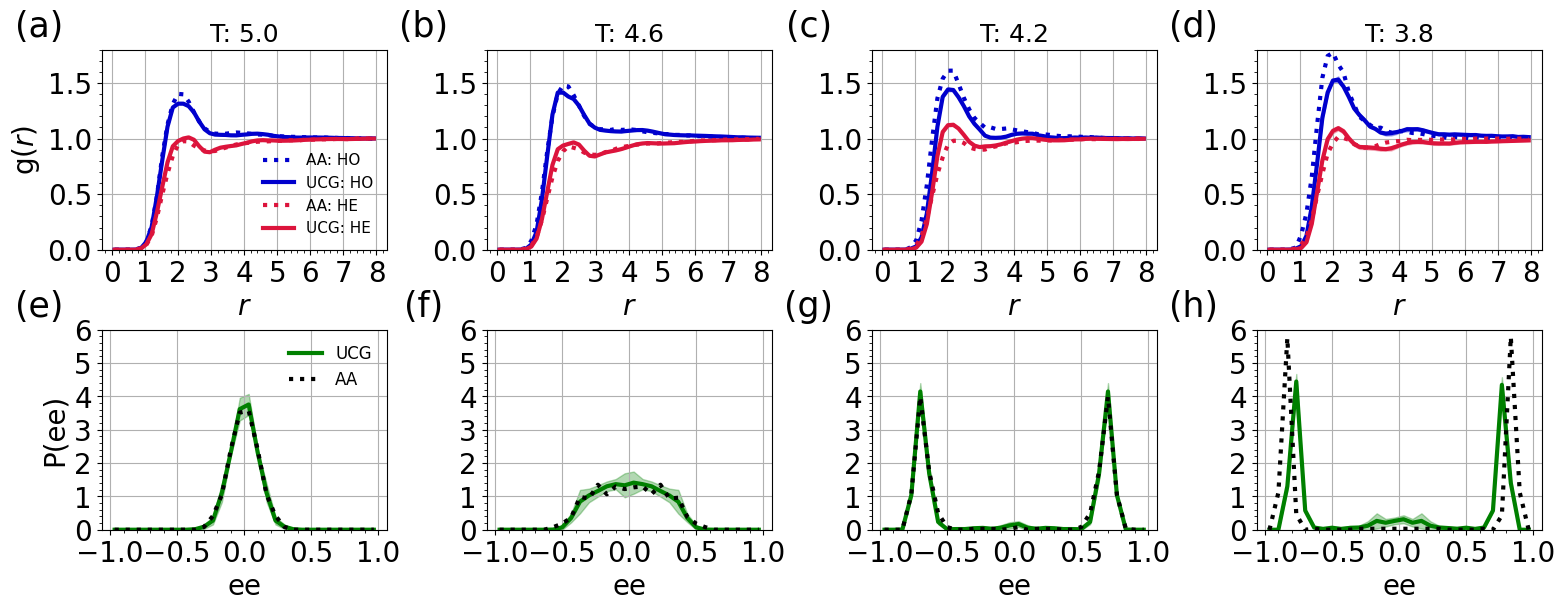

In [23]:

fig = plt.figure(figsize=(18, 6))
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.35, hspace=0.4)
grid = GridSpec(2, 4)#4)

axs = []
for i, temperature in enumerate(plot_temperatures):

    if temperature == 5.0 or temperature == 4.6:
        chiral_lag = 100
    else:
        chiral_lag = 50


    ax1 = plt.subplot(grid[0, i])
    axs.append(ax1)
    ax1.grid()


    t1_rdfs_runs = []
    t12_rdfs_runs = []
    for run in [1, 2, 3]:
        t1_rdf = bi_ucg_RDF_max_6_run[run][temperature][50000][chiral_lag][0]['t1']['rdf']*2
        t1_rdfs_runs.append(t1_rdf)
        t12_rdf = bi_ucg_RDF_max_6_run[run][temperature][50000][chiral_lag][0]['t12']['rdf']
        t12_rdfs_runs.append(t12_rdf)
        
    t1_rdfs_runs = np.array(t1_rdfs_runs)   
    t1_mean_rdf = np.mean(t1_rdfs_runs, axis=0)
    t1_std_rdf  = np.std(t1_rdfs_runs, axis=0, ddof=1)
    t12_rdfs_runs = np.array(t12_rdfs_runs)   
    t12_mean_rdf = np.mean(t12_rdfs_runs, axis=0)
    t12_std_rdf  = np.std(t12_rdfs_runs, axis=0, ddof=1)
    

    ax1.plot(symm_aa_RDF_max_6[temperature]['t1']['bin_centers'], symm_aa_RDF_max_6[temperature]['t1']['rdf']*2, color='mediumblue', ls=':', lw=3, label='AA: HO')
    ax1.plot(bi_ucg_RDF_max_6_run[1][temperature][50000][chiral_lag][0]['t1']['bin_centers'], t1_mean_rdf, color='mediumblue', lw=3, label='UCG: HO')
    ax1.fill_between(bi_ucg_RDF_max_6_run[1][temperature][50000][chiral_lag][0]['t1']['bin_centers'],
                         t1_mean_rdf - t1_std_rdf, t1_mean_rdf + t1_std_rdf, color='mediumblue', alpha=0.3)
        
    ax1.plot(symm_aa_RDF_max_6[temperature]['t12']['bin_centers'], symm_aa_RDF_max_6[temperature]['t12']['rdf']*1, color='crimson', ls=':', lw=3, label='AA: HE')
    ax1.plot(bi_ucg_RDF_max_6_run[1][temperature][50000][chiral_lag][0]['t12']['bin_centers'], t12_mean_rdf, color='crimson', lw=3, label='UCG: HE')
    ax1.fill_between(bi_ucg_RDF_max_6_run[1][temperature][50000][chiral_lag][0]['t12']['bin_centers'], 
                         t12_mean_rdf - t12_std_rdf, t12_mean_rdf + t12_std_rdf, color='crimson', alpha=0.3)
    
        
    ax1.set_title("T: " + str(temperature), fontsize=18, color="black")
    
    if i == 0:
        ax1.legend(frameon=False, fontsize=11, ncol=1, loc='lower right')
   
    ax1.set_xlabel(r"$r$")
    if i == 0:
        ax1.set_ylabel("g($r$)")
    # ax1.set_yticks([])
        
    ax1.xaxis.set_major_locator(MultipleLocator(1))
    ax1.yaxis.set_major_locator(MultipleLocator(.5))
    ax1.xaxis.set_minor_locator(AutoMinorLocator(n=5))
    ax1.yaxis.set_minor_locator(AutoMinorLocator(n=5))
    ax1.set_ylim(0.,1.8)


shift_temperature = np.linspace(0, 3, len(plot_temperatures))

for i, temperature in enumerate(plot_temperatures):

    if temperature == 5.0 or temperature == 4.6:
        chiral_lag = 100
    else:
        chiral_lag = 50
        
    ax2 = plt.subplot(grid[1, i])
    axs.append(ax2)
    ax2.grid()


    ee_hists_runs = []
    for run in [1, 2, 3]:
        h = bi_ee_symmetry_hist_run[run][temperature][50000][chiral_lag][0]['ee_symmetry_hist']
        ee_hists_runs.append(h)

    ee_hists_runs = np.array(ee_hists_runs)   
    mean_hist = np.mean(ee_hists_runs, axis=0)
    std_hist  = np.std(ee_hists_runs, axis=0, ddof=1)
    
    ax2.plot(bi_ee_symmetry_hist_run[1][temperature][50000][chiral_lag][0]['ee_symmetry_bin_centers'],
                 mean_hist, c='green', alpha=1., lw=3, label='UCG')
    ax2.fill_between(bi_ee_symmetry_hist_run[1][temperature][50000][chiral_lag][0]['ee_symmetry_bin_centers'],
                         mean_hist - std_hist, mean_hist + std_hist, color='green', alpha=0.3)

    ax2.plot(aa_ee_symmetry_hist_temperature[temperature]['ee_symmetry_bin_centers'], 
                 aa_ee_symmetry_hist_temperature[temperature]['ee_symmetry_hist'], 
                 c='black', lw=3, label='AA', ls=':')

    ax2.set_xlabel("ee")
    if i == 0:
        ax2.set_ylabel("P(ee)")
        ax2.legend(frameon=False, fontsize=12, ncol=1)
    
    ax2.xaxis.set_major_locator(MultipleLocator(.5))
    ax2.yaxis.set_major_locator(MultipleLocator(1.))
    ax2.xaxis.set_minor_locator(AutoMinorLocator(n=5))
    ax2.yaxis.set_minor_locator(AutoMinorLocator(n=5))
    ax2.set_ylim(0.,6)#0.4)


# # #####################################################################################
for i, ax in enumerate(axs):
    ax.text(-0.22, 1.2, '(' + string.ascii_lowercase[i] + ')', transform=ax.transAxes, size=25, weight='normal', va='top', ha='center')



## For SI  (T=4.5)

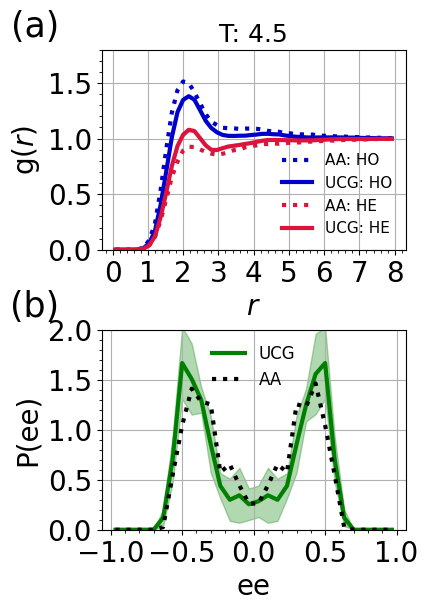

In [27]:

fig = plt.figure(figsize=(3.8, 6))
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.35, hspace=0.4)
grid = GridSpec(2, 1)

axs = []
for i, temperature in enumerate([4.5]):

    chiral_lag = 50

    ax1 = plt.subplot(grid[0, i])
    axs.append(ax1)
    ax1.grid()


    t1_rdfs_runs = []
    t12_rdfs_runs = []
    for run in [1, 2, 3]:
        t1_rdf = bi_ucg_RDF_max_6_run[run][temperature][50000][chiral_lag][0]['t1']['rdf']*2
        t1_rdfs_runs.append(t1_rdf)
        t12_rdf = bi_ucg_RDF_max_6_run[run][temperature][50000][chiral_lag][0]['t12']['rdf']
        t12_rdfs_runs.append(t12_rdf)
        
    t1_rdfs_runs = np.array(t1_rdfs_runs)   
    t1_mean_rdf = np.mean(t1_rdfs_runs, axis=0)
    t1_std_rdf  = np.std(t1_rdfs_runs, axis=0, ddof=1)
    t12_rdfs_runs = np.array(t12_rdfs_runs)   
    t12_mean_rdf = np.mean(t12_rdfs_runs, axis=0)
    t12_std_rdf  = np.std(t12_rdfs_runs, axis=0, ddof=1)
    

    ax1.plot(symm_aa_RDF_max_6[temperature]['t1']['bin_centers'], symm_aa_RDF_max_6[temperature]['t1']['rdf']*2, color='mediumblue', ls=':', lw=3, label='AA: HO')
    ax1.plot(bi_ucg_RDF_max_6_run[1][temperature][50000][chiral_lag][0]['t1']['bin_centers'], t1_mean_rdf, color='mediumblue', lw=3, label='UCG: HO')
    ax1.fill_between(bi_ucg_RDF_max_6_run[1][temperature][50000][chiral_lag][0]['t1']['bin_centers'],
                         t1_mean_rdf - t1_std_rdf, t1_mean_rdf + t1_std_rdf, color='mediumblue', alpha=0.3)
        
    ax1.plot(symm_aa_RDF_max_6[temperature]['t12']['bin_centers'], symm_aa_RDF_max_6[temperature]['t12']['rdf']*1, color='crimson', ls=':', lw=3, label='AA: HE')
    ax1.plot(bi_ucg_RDF_max_6_run[1][temperature][50000][chiral_lag][0]['t12']['bin_centers'], t12_mean_rdf, color='crimson', lw=3, label='UCG: HE')
    ax1.fill_between(bi_ucg_RDF_max_6_run[1][temperature][50000][chiral_lag][0]['t12']['bin_centers'], 
                         t12_mean_rdf - t12_std_rdf, t12_mean_rdf + t12_std_rdf, color='crimson', alpha=0.3)
    
        
    ax1.set_title("T: " + str(temperature), fontsize=18, color="black")
    
    if i == 0:
        ax1.legend(frameon=False, fontsize=11, ncol=1, loc='lower right')
   
    ax1.set_xlabel(r"$r$")
    if i == 0:
        ax1.set_ylabel("g($r$)")
    # ax1.set_yticks([])
        
    ax1.xaxis.set_major_locator(MultipleLocator(1))
    ax1.yaxis.set_major_locator(MultipleLocator(.5))
    ax1.xaxis.set_minor_locator(AutoMinorLocator(n=5))
    ax1.yaxis.set_minor_locator(AutoMinorLocator(n=5))
    ax1.set_ylim(0.,1.8)


shift_temperature = np.linspace(0, 3, len(plot_temperatures))

for i, temperature in enumerate([4.5]):

    chiral_lag = 50
        
    ax2 = plt.subplot(grid[1, i])
    axs.append(ax2)
    ax2.grid()


    ee_hists_runs = []
    for run in [1, 2, 3]:
        h = bi_ee_symmetry_hist_run[run][temperature][50000][chiral_lag][0]['ee_symmetry_hist']
        ee_hists_runs.append(h)

    ee_hists_runs = np.array(ee_hists_runs)   
    mean_hist = np.mean(ee_hists_runs, axis=0)
    std_hist  = np.std(ee_hists_runs, axis=0, ddof=1)
    
    ax2.plot(bi_ee_symmetry_hist_run[1][temperature][50000][chiral_lag][0]['ee_symmetry_bin_centers'],
                 mean_hist, c='green', alpha=1., lw=3, label='UCG')
    ax2.fill_between(bi_ee_symmetry_hist_run[1][temperature][50000][chiral_lag][0]['ee_symmetry_bin_centers'],
                         mean_hist - std_hist, mean_hist + std_hist, color='green', alpha=0.3)

    ax2.plot(aa_ee_symmetry_hist_temperature[temperature]['ee_symmetry_bin_centers'], 
                 aa_ee_symmetry_hist_temperature[temperature]['ee_symmetry_hist'], 
                 c='black', lw=3, label='AA', ls=':')

    ax2.set_xlabel("ee")
    if i == 0:
        ax2.set_ylabel("P(ee)")
        ax2.legend(frameon=False, fontsize=12, ncol=1)
    
    ax2.xaxis.set_major_locator(MultipleLocator(.5))
    ax2.yaxis.set_major_locator(MultipleLocator(.5))
    ax2.xaxis.set_minor_locator(AutoMinorLocator(n=5))
    ax2.yaxis.set_minor_locator(AutoMinorLocator(n=5))
    ax2.set_ylim(0.,2.)


# # #####################################################################################
for i, ax in enumerate(axs):
    ax.text(-0.22, 1.2, '(' + string.ascii_lowercase[i] + ')', transform=ax.transAxes, size=25, weight='normal', va='top', ha='center')



## For snapshots

In [120]:
temperature = 4.5
bi_ee_run[1][temperature][50000][50][0][147]

0.496

In [119]:

np.argwhere( (np.abs(bi_ee_run[1][temperature][50000][50][0])  < 0.501) & (np.abs(bi_ee_run[1][temperature][50000][50][0])  > 0.495) )


array([[ 90],
       [147],
       [217],
       [334],
       [480]])

In [128]:
temperature = 4.5
full_aa_ee[temperature][235]

-0.496

In [125]:

np.argwhere( (np.abs(full_aa_ee[temperature])  < 0.501) & (np.abs(full_aa_ee[temperature])  > 0.495) )


array([[  217],
       [  235],
       [  252],
       [  265],
       [  269],
       [  277],
       [  734],
       [  756],
       [  770],
       [  795],
       [  808],
       [  815],
       [  816],
       [  821],
       [  829],
       [  939],
       [  940],
       [  968],
       [ 1014],
       [ 1041],
       [ 1043],
       [ 1054],
       [ 1151],
       [ 1152],
       [ 1175],
       [ 1199],
       [ 1209],
       [ 1218],
       [ 1258],
       [ 1317],
       [ 1326],
       [ 1457],
       [ 1531],
       [ 1794],
       [ 1795],
       [ 1806],
       [ 2041],
       [ 2133],
       [ 2164],
       [ 2172],
       [ 2189],
       [ 2232],
       [ 2586],
       [ 2588],
       [ 2612],
       [ 2647],
       [ 2648],
       [ 3025],
       [ 3034],
       [ 3051],
       [ 3090],
       [ 3095],
       [ 3102],
       [ 3177],
       [ 3194],
       [ 3195],
       [ 3269],
       [ 3271],
       [ 3273],
       [ 3343],
       [ 4165],
       [ 4190],
       [

In [87]:
full_aa_ee[temperature].shape

(14409,)